## Preparation

### Libraries import & metadata storage definitions

In [67]:
import os
import numpy as np
import torch
from time import time

from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.decomposition import TruncatedSVD

from matplotlib import pyplot as plt, colors, cm

In [3]:
checkpoint_dir = "checkpoints"
graph_dir = "graphs"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Common key functions: plots & training

In [418]:
def plot_metric(trains: list, 
                tests: list, 
                epochs: int, 
                model_name: str = "model",
                dataset_name: str = "dataset",
                metric_name: str = "metric",
                graph_dir: str = "graphs"):
    
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        [i+1 for i in range(epochs)],
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label="train " + metric_name
    )
    ax.plot(
        [i+1 for i in range(epochs)],
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label="test " + metric_name
    )
    ax.set(
        title=f"{model_name} {metric_name} on {dataset_name} for {epochs} epochs",
        xlabel="epochs", xlim=(-1, epochs+1), xticks=[i for i in range(0, epochs+1, 5)],
        ylabel=metric_name
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}_{epochs}epochs.png"))
    

def centralize_colormap(values, 
                        center: float = 0):
    values_min = values.min()
    values_max = values.max()
    border = max(abs(values_min), abs(values_max))
    
    return colors.TwoSlopeNorm(
        vmin=-border,
        vcenter=center, 
        vmax=border
    )


def plot_heatmap(values,
                 figsize = None,
                 cmap_name: str = "seismic",
                 title: str = "Weights heatmap"):    
    plt.figure(figsize=figsize or (25, 3))
    plt.imshow(
        values, 
        origin="lower",
        cmap=cmap_name, 
        norm=centralize_colormap(values),
        extent=(0, len(values[0]) + 1, 0, len(values) + 1)
    )  
    plt.title(title)  
    plt.colorbar()  
    plt.show() 


def plot_colored_barplot(values,
                         values_color,
                         cmap_name: str = "seismic",
                         edge_color: str = "black",
                         title: str = "Values barplot",
                         x_label: str = "",
                         y_label: str = ""):
    fig, ax = plt.subplots(figsize=(25, 5))
    
    values_cmap = plt.get_cmap(cmap_name)
    norm = centralize_colormap(values_color)
    ax.bar(
        [i for i in range(len(values))],
        values, 
        color=values_cmap(norm(values_color)),
        edgecolor=edge_color
    )
    
    scalar_map = cm.ScalarMappable(
        cmap=values_cmap, 
        norm=norm
    )
    scalar_map.set_array([])
    colorbar = plt.colorbar(scalar_map, ax=ax)
    colorbar.set_label("Percentage of variance explained")
    
    ax.set(
        title=title,
        xlabel=x_label,
        ylabel=y_label
    )
    plt.grid(True, alpha=0.3, zorder=0)
    plt.show() 

In [7]:
def train_epoch(model: torch.nn.Module,
                train_loader: DataLoader,
                optimizer,
                criterion,
                device: torch.device = torch.device("cpu")):
    model.train()
    
    train_loss = 0.0
    correct = 0
    total = 0
        
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
            
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
            
        loss.backward()
        optimizer.step()
            
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    train_acc = 100. * correct / total

    return train_loss, train_acc


def validate_epoch(model: torch.nn.Module,
                   test_loader: DataLoader,
                   criterion,
                   device: torch.device = torch.device("cpu")):
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0
        
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
                
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
    test_acc = 100. * correct / total

    return test_loss, test_acc


def train_n_epochs(model: torch.nn.Module,
                   train_loader: DataLoader, 
                   test_loader: DataLoader,
                   optimizer,
                   criterion,
                   scheduler,
                   model_name: str = "",
                   dataset_name: str = "dataset",
                   device: torch.device = torch.device("cpu"),
                   epochs: int = 150,
                   checkpoint_dir: str = "checkpoints",
                   with_plots: bool = True,
                   graph_dir: str = "",
                   verbose: bool = True):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    model_name = model_name or model.__class__.__name__
    model.to(device)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []    
    best_acc = 0
    
    for epoch in range(epochs):
        print(f"Epoch {epoch} started...")
        start_time = time()
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        scheduler.step()
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "acc": test_acc
        }, os.path.join(checkpoint_dir, f"{model_name}_{dataset_name}_last.pth"))
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "acc": test_acc
            }, os.path.join(checkpoint_dir, f"{model_name}_{dataset_name}_best.pth"))
        
        if verbose:
            epoch_time = time() - start_time
            print(
                f"Epoch: {epoch+1}/{epochs} | "
                f"Time: {epoch_time:.2f}s | "
                f"Train Loss: {train_loss/len(train_loader):.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Test Loss: {test_loss/len(test_loader):.4f} | "
                f"Test Acc: {test_acc:.2f}% | "
                f"LR: {scheduler.get_last_lr()[0]:.6f}"
            )

    if with_plots:
        graph_dir = graph_dir or f"graphs_{model_name}_{epochs}epochs"
        os.makedirs(graph_dir, exist_ok=True)
        plot_metric(train_losses, test_losses, epochs, model_name=model_name, dataset_name=dataset_name, metric_name="Loss", graph_dir=graph_dir)
        plot_metric(train_accs, test_accs, epochs, model_name=model_name, dataset_name=dataset_name, metric_name="Accuracy", graph_dir=graph_dir)
    
    print(f"Best accuracy: {best_acc}%")
    
    return train_losses, train_accs, test_losses, test_accs

## Dataset download & instantiation

### ImageNet-1K

В работе рассматривается задача классификации изображений, для которой используются модель [семейства RegNet](https://docs.pytorch.org/vision/main/models/regnet.html) версии RegNet_X_3_2_GF и датасет [ImageNet-1K (ILSVRC2017)](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview). 

Датасет ImageNet содержит высокого (различного) разрешения, каждое из которых аннотировано с использованием синсетов WordNet и соотносится с 1 или более из 1000 классов; классы не сбалансированы. Подсеты имеют следующую мощность:
- train - 1,3 млн изображений,
- val - 50 тыс изображений,
- test - 100 тыс изображений.

Модель для ускорения обучения инициализируется весами, предобученными на датасете ImageNet со следующими метриками точности:
- acc1: 78.364,
- acc5: 93.992

без дообучения.

In [ ]:
def make_val_loader_imagenet(val_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4):
    transforms_val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        ),
    ])

    imagenet_val = datasets.ImageNet(
        root=val_dir, 
        split="val", 
        transform=transforms_val
    )

    return DataLoader(
        imagenet_val, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=num_workers, 
        pin_memory=True
    )

In [ ]:
dataset_dir_imagenet = "D:/imagenet"
dataset_name = "ImageNet"
n_classes = 1000
batch_size = 32
num_workers = 4

In [ ]:
print(f"[ ] Creating dataset {dataset_name}...")
val_loader = make_val_loader_imagenet(dataset_dir_imagenet, batch_size, num_workers)
print(f"[V] Dataset {dataset_name} created")

### CIFAR-100 

В работе рассматривается задача классификации изображений, для которой используются модель [семейства RegNet](https://docs.pytorch.org/vision/main/models/regnet.html) версии RegNet_X_3_2_GF и датасет [CIFAR-100](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR100.html). 

Датасет CIFAR-100 содержит 60 000 цветных изображений (50 000 в подсете train и 10 000 в подсете test) размерности 32х32 пикселя, каждое из которых соотносится ровно с 1 из 100 классов. Классы сбалансированы: каждый класс представлен 600 изображениями.

Модель для ускорения обучения инициализируется весами, предобученными на датасете [ImageNet](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview) со следующими метриками точности:
- acc1: 78.364,
- acc5: 93.992

с дальнейшей адаптацией архитектуры под CIFAR-100.

In [8]:
def make_train_loader_cifar100(data_dir: str, 
                               batch_size: int = 256, 
                               num_workers: int = 4):
    transforms_train = transforms.Compose([
        transforms.RandomCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=True,
        download=True,
        transform=transforms_train
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

def make_val_loader_cifar100(data_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4):
    transforms_val = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=False,
        download=True,
        transform=transforms_val
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

In [9]:
dataset_dir_cifar100 = "D:/cifar100"
dataset_name = "CIFAR100"
n_classes = 100
picture_size = 32

batch_size = 128  # takes 94% of RAM available on the laptop
num_workers = 4

In [10]:
print(f"[ ] Creating dataloaders for dataset {dataset_name}...")
train_loader = make_train_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
val_loader = make_val_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
print(f"[V] Dataloaders for dataset {dataset_name} created")

[ ] Creating dataloaders for dataset CIFAR100...
[V] Dataloaders for dataset CIFAR100 created


## Model preparation

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name() if device.type == "cuda" else device.type)

Device: NVIDIA GeForce GTX 1650


### RegNetX_3_2 download & instantiation

In [12]:
def adapt_model_cifar100(model, 
                         n_classes: int,
                         in_channels: int = 3, 
                         out_channels: int = 32,
                         kernel_size: int = 3,
                         stride: int = 1, 
                         padding: int = 1,
                         bias: bool = False):
    model.stem[0] = torch.nn.Conv2d(
        in_channels = in_channels, out_channels = out_channels, 
        kernel_size=kernel_size, stride=stride, padding=padding, 
        bias=bias
    )
    model.fc = torch.nn.Linear(model.fc.in_features, n_classes)

In [180]:
print("[ ] Instantiating model...")
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
# regnetx_16 = models.regnet_x_32gf(weights=models.RegNet_X_32GF_Weights.DEFAULT, progress=True)
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.to(device)
regnetx_3_2_name = "RegNetX_3_2"
print("[V] Model instantiated and adapted for CIFAR-100")

[ ] Instantiating model...
[V] Model instantiated and adapted for CIFAR-100


In [170]:
max_lr = 0.01
weight_decay = 0.001

criterion = CrossEntropyLoss()
optimizer = AdamW(regnetx_3_2.parameters(), lr=max_lr, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

### Fine-tuning RegNetX_3_2 on CIFAR-100

We can pre-finetune model...

In [240]:
print("[ ] Finetuning model on CIFAR-100...")
train_losses, train_accs, test_losses, test_accs = train_n_epochs(
    regnetx_3_2, 
    train_loader, 
    val_loader, 
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    model_name=regnetx_3_2_name,
    device=device, 
    epochs=10000,
    checkpoint_dir=checkpoint_dir,
    graph_dir=graph_dir
)
print("[V] Model finetuned on CIFAR-100")

[ ] Finetuning model on CIFAR-100...
Epoch 0 started...
Epoch: 1/10000 | Time: 141.75s | Train Loss: 0.1282 | Train Acc: 96.15% | Test Loss: 3.3820 | Test Acc: 56.63% | LR: 0.009999
Epoch 1 started...
Epoch: 2/10000 | Time: 142.08s | Train Loss: 0.1287 | Train Acc: 96.12% | Test Loss: 3.3582 | Test Acc: 56.72% | LR: 0.009998
Epoch 2 started...
Epoch: 3/10000 | Time: 142.32s | Train Loss: 0.1260 | Train Acc: 96.12% | Test Loss: 3.4159 | Test Acc: 56.78% | LR: 0.009994
Epoch 3 started...
Epoch: 4/10000 | Time: 142.78s | Train Loss: 0.1227 | Train Acc: 96.11% | Test Loss: 3.3889 | Test Acc: 56.59% | LR: 0.009990
Epoch 4 started...
Epoch: 5/10000 | Time: 143.84s | Train Loss: 0.1297 | Train Acc: 96.12% | Test Loss: 3.3824 | Test Acc: 56.75% | LR: 0.009985
Epoch 5 started...
Epoch: 6/10000 | Time: 143.26s | Train Loss: 0.1236 | Train Acc: 96.20% | Test Loss: 3.3918 | Test Acc: 56.75% | LR: 0.009978
Epoch 6 started...
Epoch: 7/10000 | Time: 142.32s | Train Loss: 0.1254 | Train Acc: 96.09% | 

KeyboardInterrupt: 

Or download it fine-tuned from checkpoint:

In [375]:
checkpoint_path = "checkpoints/RegNetX_3_2_CIFAR100_57.34.pth"
print("[ ] Loading checkpoints from path:", checkpoint_path, "...")
checkpoint = torch.load(checkpoint_path)
print("[V] Checkpoints loaded")

print("[ ] Loading fine-tuned model for CIFAR-100...")
regnetx_3_2 = models.regnet_x_3_2gf()
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
regnetx_3_2.to(device)
print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"])

[ ] Loading checkpoints from path: checkpoints/RegNetX_3_2_CIFAR100_57.34.pth ...
[V] Checkpoints loaded
[ ] Loading fine-tuned model for CIFAR-100...
[V] Fine-tuned model loaded, its accuracy: 57.34


In [376]:
print("[ ] Validating model to check accuracy...")
_, checkpoint_acc = validate_epoch(regnetx_3_2, val_loader, criterion, device)
print("[V] Model has accuracy:", checkpoint_acc)

[ ] Validating model to check accuracy...
[V] Model has accuracy: 57.34


## Main pipeline

### Pipeline: validation, binarization, weights fuse, significant semantic features cont + analysis

In [379]:
seed = 42
torch.manual_seed(seed)

@torch.inference_mode()
def validate_top1_top5_time(model, 
                            loader: DataLoader, 
                            device: torch.device):
    model.eval()
    top1_correct = 0
    top5_correct = 0
    total = 0
    
    start_time = time()

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        _, preds = logits.topk(5, dim=1, largest=True, sorted=True)

        correct = preds.eq(targets.view(-1, 1))
        top1_correct += correct[:, :1].sum().item()
        top5_correct += correct.sum().item()
        total += targets.size(0)
        
    valid_time = time() - start_time

    return (top1_correct / total * 100,
            top5_correct / total * 100,
            valid_time)


def binarize_hook(module, input):
    x, = input
    # x_bin = 2 ** (x+1).log2().round() - 1                       #-0.1%  for ResNet50 on CIFAR-10
    x_pseudobin = 2 ** (x+1).log2().mul(2).round().mul(0.5) - 1  #-0.01% for ResNet50 on CIFAR-10
    
    # x_pseudobin_counts = x_pseudobin.unique(return_counts=True)
    # x_bin = x_pseudobin_counts[0][ torch.topk(x_pseudobin_counts[1], 2).indices ]
    return (x_pseudobin,) 


def fuse_avgpool_linear(model, 
                        input_size: int):
    device = next(model.parameters()).device
    
    weights = model.fc.weight.data  # [100, 1008] for RegNetX_3_2 on CIFAR-100
    bias = model.fc.bias.data if (model.fc.bias is not None) else torch.zeros(weights.shape[0])
    
    with torch.no_grad():
        random_input = torch.randn(1, 3, input_size, input_size).to(device)
        features = model.stem(random_input)
        features = model.trunk_output(features)
        features = model.avgpool(features)  # shape = [batch, channels, H, W] = [1, 1008, 1, 1] for RegNetX_3_2 on CIFAR-100
        H, W = features.shape[-2:]
    
    divisor = H * W
    weights_fused = weights.repeat(1, divisor) / divisor
    
    return weights_fused.to(device), bias.to(device)


def replace_linear(model,
                   new_weights,
                   new_bias = None):
    device = next(model.parameters()).device
    model.fc.weights = new_weights.to(device)
    if new_bias is not None:
        model.fc.bias = new_bias.to(device)
    

def mostleast_signific_features(weights: torch.Tensor, 
                                feature_idx: int, 
                                dataloader: DataLoader, 
                                top_k: int = 5):    
    class_weights = np.argsort(abs(weights[:, feature_idx]))
    class_names = dataloader.dataset.classes # type: ignore
    
    return {
        "top_classes_ids":        class_weights[-top_k:],
        "top_classes_names":      [class_names[class_id] for class_id in class_weights[-top_k:]],
        "top_classes_weights":    weights[class_weights[-top_k:]],
        "bottom_classes_ids":     class_weights[:top_k],
        "bottom_classes_names":   [class_names[class_id] for class_id in class_weights[:top_k]],
        "bottom_classes_weights": weights[class_weights[:top_k]]
    }
    
def mostleast_signific_classes(weights: torch.Tensor, 
                               feature_idx: int, 
                               dataloader: DataLoader, 
                               top_k: int = 5):
    class_weights = np.argsort(abs(weights[:, feature_idx]))
    class_names = dataloader.dataset.classes # type: ignore
    
    return {
        "top_classes_ids":        class_weights[-top_k:],
        "top_classes_names":      [class_names[class_id] for class_id in class_weights[-top_k:]],
        "top_classes_weights":    weights[class_weights[-top_k:]],
        "bottom_classes_ids":     class_weights[:top_k],
        "bottom_classes_names":   [class_names[class_id] for class_id in class_weights[:top_k]],
        "bottom_classes_weights": weights[class_weights[:top_k]]
    }

In [378]:
print("\n1.5. Validating model before binarizing:\n")
top1_orig, top5_orig, val_time = validate_top1_top5_time(regnetx_3_2, val_loader, device)
print("    Top-1 Accuracy: ", top1_orig)
print("    Top-5 Accuracy: ", top5_orig)
print("    Validation time:", val_time)


1.5. Validating model before binarizing:

    Top-1 Accuracy:  57.34
    Top-5 Accuracy:  81.0
    Validation time: 10.026110649108887


In [ ]:
print("\n2. Binarizing features...\n")
regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook)

print("\n2.5. Validating model after binarizing:\n")
top1_bin, top5_bin, val_time = validate_top1_top5_time(regnetx_3_2, val_loader, device)
print(f"    Top-1 Accuracy: {top1_bin:.4f}, drop: {top1_orig - top1_bin:.4f}")
print(f"    Top-5 Accuracy: {top5_bin:.4f}, drop: {top5_orig - top5_bin:.4f}")
print("    Validation time:", val_time)


2. Binarizing features...


2.5. Validating model after binarizing:

    Top-1 Accuracy: 57.1000, drop: 0.2400000000000091
    Top-5 Accuracy: 80.6300, drop: 0.37000000000000455
    Validation time: 10.082445621490479


In [381]:
print("\n3. Avgpool and linear layers fusing...\n")
weights_fused, bias_fused = fuse_avgpool_linear(regnetx_3_2, picture_size)
print("    Fused weight matrix shape:", weights_fused.shape)  # [100, 1008*H*W]


3. Avgpool and linear layers fusing...

    Fused weight matrix shape: torch.Size([100, 1008])


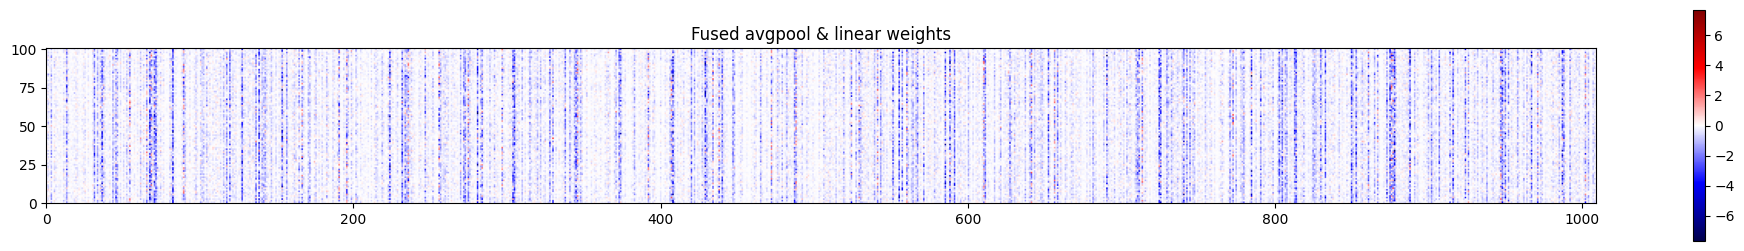

In [166]:
plot_heatmap(weights_fused.cpu(), title="Fused avgpool & linear weights")

### Significant features extraction & binarization

In [395]:
torch.manual_seed(seed)

n_svd_components = 50

print("\n4. SVD...\n")
svd = TruncatedSVD(n_components=n_svd_components, random_state=seed)
weights_reduced = svd.fit_transform(weights_fused.cpu())
print("    Explained variance ratio:", svd.explained_variance_ratio_.sum())


4. SVD...

    Explained variance ratio: 0.79665077


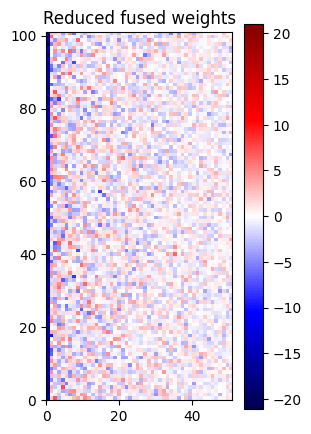

In [399]:
plot_heatmap(weights_reduced, figsize=(3,5), title="Reduced fused weights")


5. Extracting significant features...



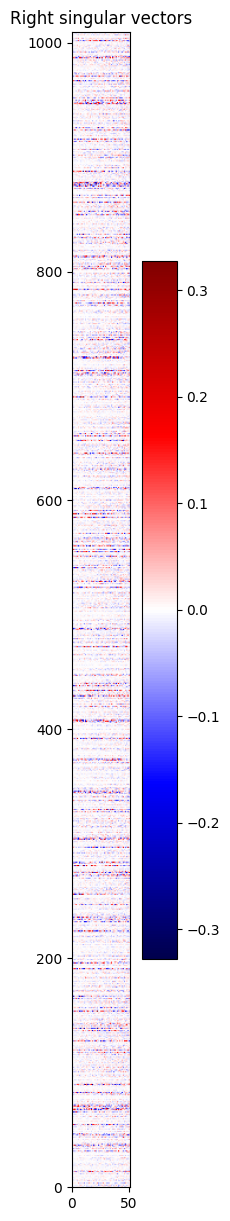

In [402]:
print("\n5. Extracting significant features...\n")
svd_right_sing_vecs = svd.components_  # [n_svd_components, 1008*H*W]
plot_heatmap(
    np.transpose(svd_right_sing_vecs), 
    figsize=(3, 15),
    title="Right singular vectors"
)

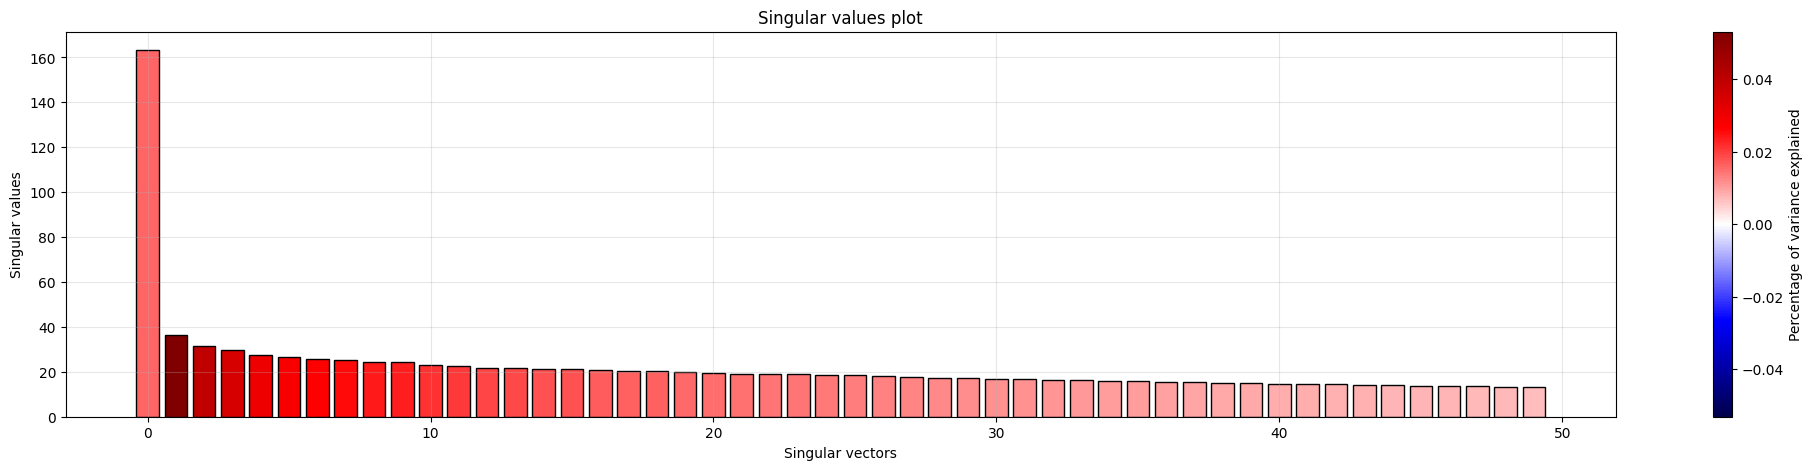

In [419]:
svd_sing_values = svd.singular_values_
svd_expl_var_ratio = svd.explained_variance_ratio_

plot_colored_barplot(
    values=svd_sing_values,
    values_color=svd_expl_var_ratio,
    title="Singular values plot",
    x_label="Singular vectors",
    y_label="Singular values"
)

In [407]:
print("\n6. Counting significant features...\n")

signific_thresholds = [0.01, 0.1, 0.15, 0.2, 0.25, 0.5]
signific_features_ns = [ np.sum(np.abs(svd_right_sing_vecs) >= threshold) 
                         for threshold in signific_thresholds ]

for i in range(len(signific_thresholds)):
    print(
        f"    Percent of significant binary features (>= {signific_thresholds[i]}):", 
        " " * (i % 2),
        f"{signific_features_ns[i] / svd_right_sing_vecs.size:.2%}"        
    )
print("    of all features after SVD")


6. Counting significant features...

    Percent of significant binary features (>= 0.01):  45.15%
    Percent of significant binary features (>= 0.1):   2.30%
    Percent of significant binary features (>= 0.15):  0.72%
    Percent of significant binary features (>= 0.2):   0.17%
    Percent of significant binary features (>= 0.25):  0.05%
    Percent of significant binary features (>= 0.5):   0.00%
    of all features after SVD


In [406]:
print("\n6. Binarizing significant features...\n")

signific_threshold = 0.15

binary_features = (abs(svd_right_sing_vecs) > signific_threshold).astype(int)
print("    Binary features:\n", binary_features)
print("    Binary features shape:", binary_features.shape)


6. Binarizing significant features...

    Binary features:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
    Binary features shape: (50, 1008)


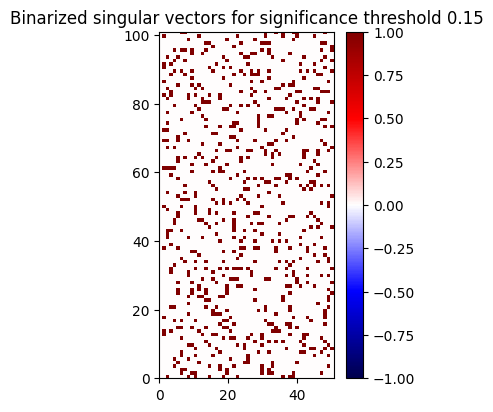

In [238]:
plot_heatmap(
    np.transpose(binary_features), 
    figsize=(3, 4.5),
    title=f"Binarized singular vectors for significance threshold {signific_threshold}"
)

In [99]:
print("Top-3 singular values:                ", svd_sing_values[:3])
print("Top-3 (according) explained variences:", svd_expl_var_ratio[:3])

Top-3 singular values:                 [163.30693   36.425407  31.409609]
Top-3 (according) explained variences: [0.41053113 0.03111935 0.02349741]


In [ ]:
print("\n7.1 Significant features semantics analysis:\n")
top_features_significance = mostleast_signific_classes(weights_fused.cpu(), 0, val_loader)

print("    Most significant classes ids:   ", top_classes_significance["top_classes_ids"]) 
print("    Least significant classes ids:  ", top_classes_significance["bottom_classes_ids"]) 

print("\n7.2 Significant features semantics analysis:\n")
top_classes_significance = mostleast_signific_features(weights_fused.cpu(), 0, val_loader)

print("    Most significant classes ids:   ", top_classes_significance["top_classes_ids"]) 
print("    Most significant classes names: ", top_classes_significance["top_classes_names"]) 
print("    Least significant classes ids:  ", top_classes_significance["bottom_classes_ids"]) 
print("    Least significant classes names:", top_classes_significance["bottom_classes_names"]) 


7. Significant features semantics analysis:

    Most significant classes ids:    tensor([ 1, 41, 31, 98, 65])
    Most significant classes names:  ['aquarium_fish', 'lawn_mower', 'elephant', 'woman', 'rabbit']
    Least significant classes ids:   tensor([ 0, 68, 87, 97, 83])
    Least significant classes names: ['apple', 'road', 'television', 'wolf', 'sweet_pepper']

7. Significant features semantics analysis:

    Most significant classes ids:    tensor([ 1, 41, 31, 98, 65])
    Most significant classes names:  ['aquarium_fish', 'lawn_mower', 'elephant', 'woman', 'rabbit']
    Least significant classes ids:   tensor([ 0, 68, 87, 97, 83])
    Least significant classes names: ['apple', 'road', 'television', 'wolf', 'sweet_pepper']


## ADD-ONS

### Add-on: SVD components search

In [225]:
torch.manual_seed(seed)

def elbow_method_svd(weights, components_set):
    metrics = {
        "n_significant_features_0.1": [],
        "n_significant_features_0.15": [],
        "n_significant_features_0.2": [],
        "n_significant_features_0.25": [],
        "n_significant_features_0.5": [],
        "explained_variances": [],
        "reconstruction_rmse": [],
        "decomposition_time": []
    }
    
    for n_components in components_set:
        start_time = time()
        svd = TruncatedSVD(n_components=n_components, random_state=seed)
        X_reduced = svd.fit_transform(weights)
        decomp_time = time() - start_time
        weights_reconstructed = svd.inverse_transform(X_reduced)
        
        for threshold in signific_thresholds:
            metrics[f"n_significant_features_{threshold}"].append(np.sum(np.abs(svd.components_) >= threshold))
        metrics["decomposition_time"].append(decomp_time)
        metrics["explained_variances"].append(svd.explained_variance_ratio_.sum())
        metrics["reconstruction_rmse"].append(np.mean((weights - weights_reconstructed) ** 2))
    
    return metrics

In [226]:
n_components_options = [i for i in range(5, 105, 5)]
metrics = elbow_method_svd(weights_fused.cpu().t().numpy(), n_components_options)

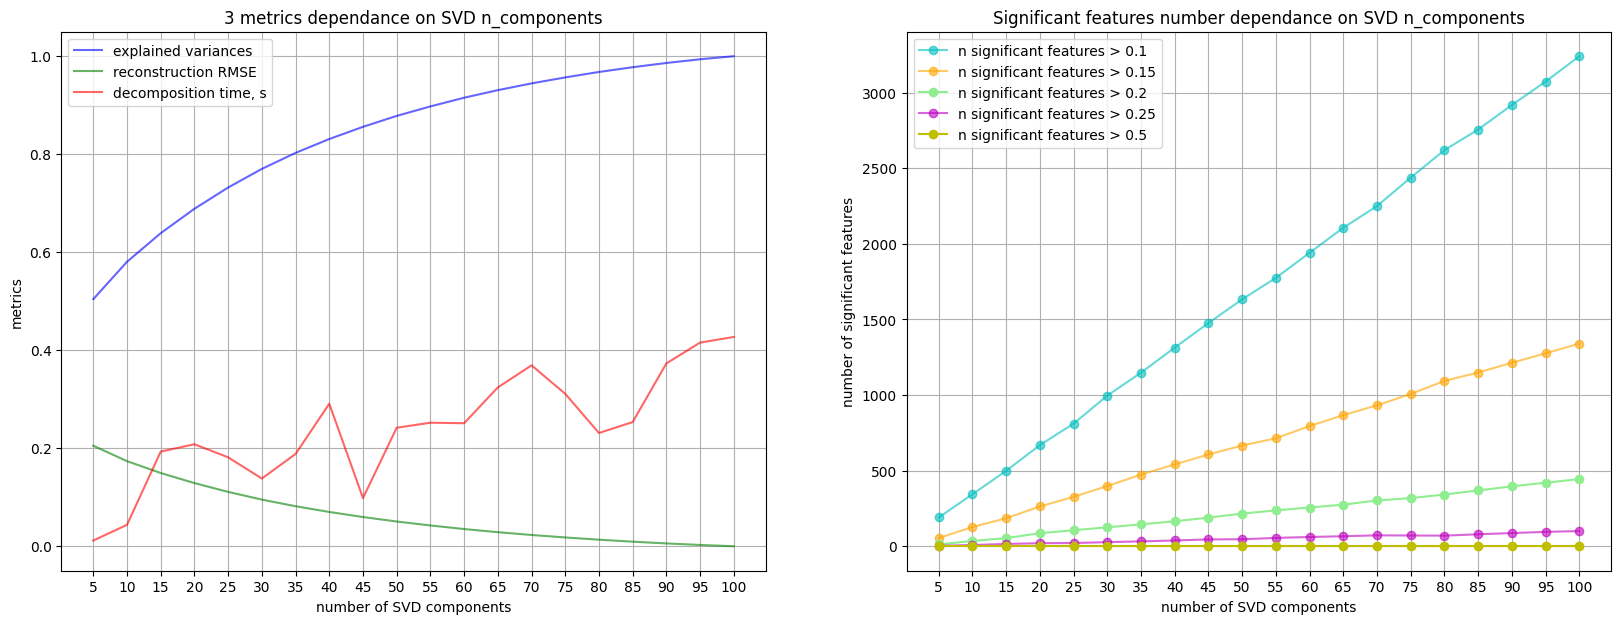

In [233]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(n_components_options, metrics["explained_variances"],   "b", alpha=0.6, label="explained variances")
axs[0].plot(n_components_options, metrics["reconstruction_rmse"], "g", alpha=0.6, label="reconstruction RMSE")
axs[0].plot(n_components_options, metrics["decomposition_time"],    "r", alpha=0.6, label="decomposition time, s")

axs[0].set(
       xticks=n_components_options,
       xlabel="number of SVD components", 
       ylabel="metrics",
       title="3 metrics dependance on SVD n_components"
)
axs[0].grid(zorder=0)
axs[0].legend()


axs[1].plot(n_components_options, metrics["n_significant_features_0.1"],  "c-o", alpha=0.6, label="n significant features > 0.1")
axs[1].plot(n_components_options, metrics["n_significant_features_0.15"], "orange", marker="o", alpha=0.6, label="n significant features > 0.15")
axs[1].plot(n_components_options, metrics["n_significant_features_0.2"],  "lightgreen", marker="o",label="n significant features > 0.2")
axs[1].plot(n_components_options, metrics["n_significant_features_0.25"], "m-o", alpha=0.6, label="n significant features > 0.25")
axs[1].plot(n_components_options, metrics["n_significant_features_0.5"],  "y-o", label="n significant features > 0.5")

axs[1].set(
       xticks=n_components_options,
       xlabel="number of SVD components", 
       ylabel="number of significant features",
       title="Significant features number dependance on SVD n_components"
)
axs[1].grid(zorder=0)
axs[1].legend()

plt.show()

In [ ]:
for n_compts, n_sign_feats in enumerate(metrics["n_significant_features_0.25"]):
    new_n_compts = (n_compts + 1) * 5
    
    if new_n_compts < 10: spaces = "   "
    elif new_n_compts >= 100: spaces = " "
    else: spaces = "  "
    
    print(new_n_compts, ":", spaces, n_sign_feats)

5 :     3
10 :    8
15 :    15
20 :    20
25 :    21
30 :    27
35 :    32
40 :    38
45 :    45
50 :    46
55 :    55
60 :    61
65 :    66
70 :    72
75 :    71
80 :    70
85 :    79
90 :    87
95 :    95
100 :   100


In [215]:
max_n_sign_features = max(metrics["n_significant_features_0.25"])

print("Number of largest sign.features >0.25: ", max_n_sign_features)
print("The n_components with this number:     ", [ n_components_options[i] for i in np.where(metrics["n_significant_features_0.25"] == max_n_sign_features)[0] ])

Number of largest sign.features >0.25:  100
The n_components with this number:      [100]


### SVD significant features number dependance on significance threshold

In [367]:
torch.manual_seed(seed)

def plot_n_signific_features_of_n_compts(weights,
                                         components_set,
                                         signific_feats_borders: tuple = (0, 0.5),
                                         cmap_name: str = "winter",
                                         in_part: bool = False):
    fig, ax = plt.subplots(figsize=(20, 7))
    n_components_cmap = plt.get_cmap(cmap_name)

    max_n_components = max(components_set)
    thresholds = np.linspace(signific_feats_borders[0], signific_feats_borders[1], num=100)
    yticks_n_compts = []
    
    for n_components in components_set:
        svd = TruncatedSVD(n_components=n_components, random_state=seed)
        svd.fit(weights)
        
        ns_signific_features = [np.sum(np.abs(svd.components_) >= threshold) / svd.components_.size for threshold in thresholds] \
                               if in_part else \
                               [np.sum(np.abs(svd.components_) >= threshold) for threshold in thresholds]
        ax.plot(
            thresholds,
            ns_signific_features,
            color=n_components_cmap(n_components / max_n_components),
            alpha=0.6,
            label=f"n_signific_features of {n_components} SVD components"
        )
        yticks_n_compts.append(ns_signific_features[0])

    if in_part:
        yticks_n_compts = [i * (max(yticks_n_compts) / 20) for i in range(0, 21)]
    else:
        yticks_n_compts = [0] + yticks_n_compts \
                          if (len(components_set) >= 10) else \
                          [i * (max(yticks_n_compts) // 10) for i in range(0, 11)]
    
    scaling_name = "Part" if in_part else "Number"
    ax.set(
        xticks=[i * 0.01 for i in range( int(signific_feats_borders[0]*100), int(signific_feats_borders[1]*100) + 1 )],
        xlabel="Significance thresholds",
        yticks=yticks_n_compts,
        ylabel=scaling_name + " of significant features",
        title=scaling_name + " of significant features dependance on SVD n_components"
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()
    plt.show()

#### Lots of graphs

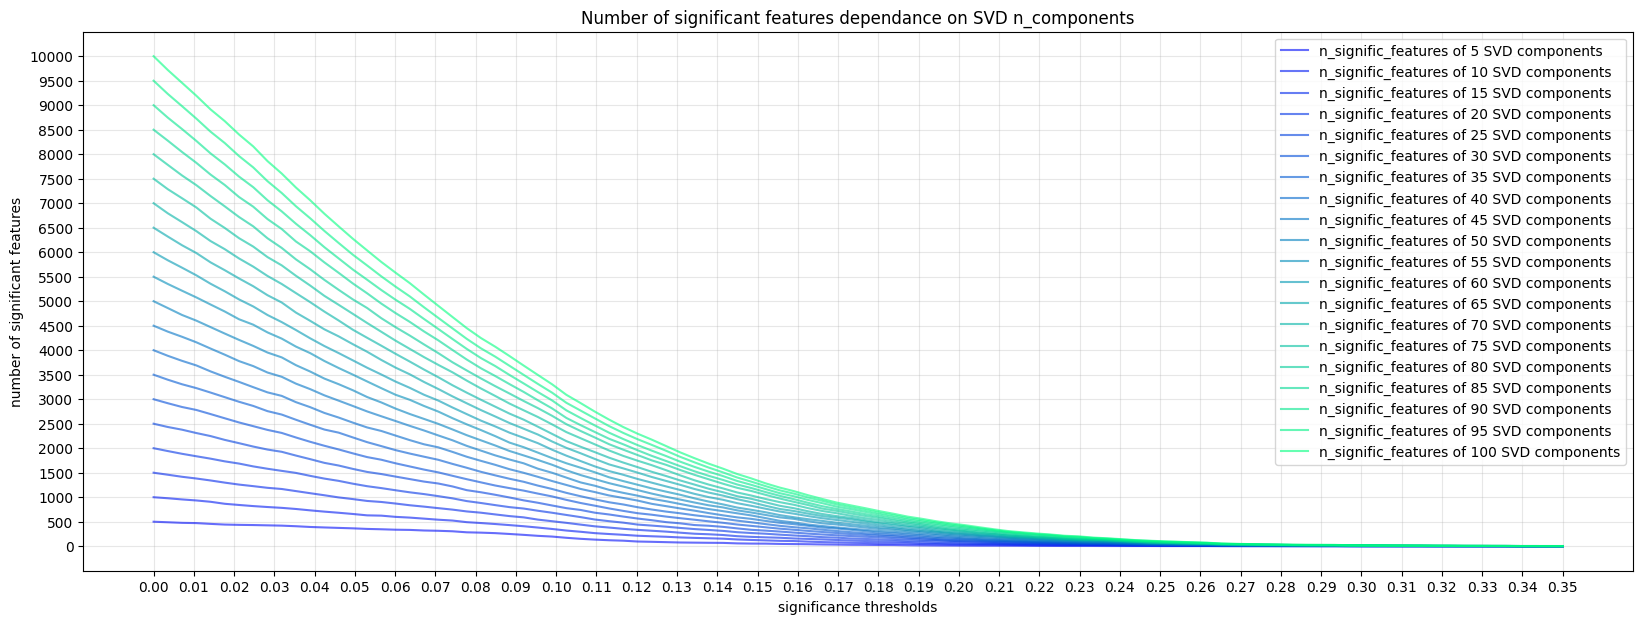

In [314]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().t().numpy(), 
    components_set=n_components_options,
    signific_feats_borders=(0, 0.35)
)

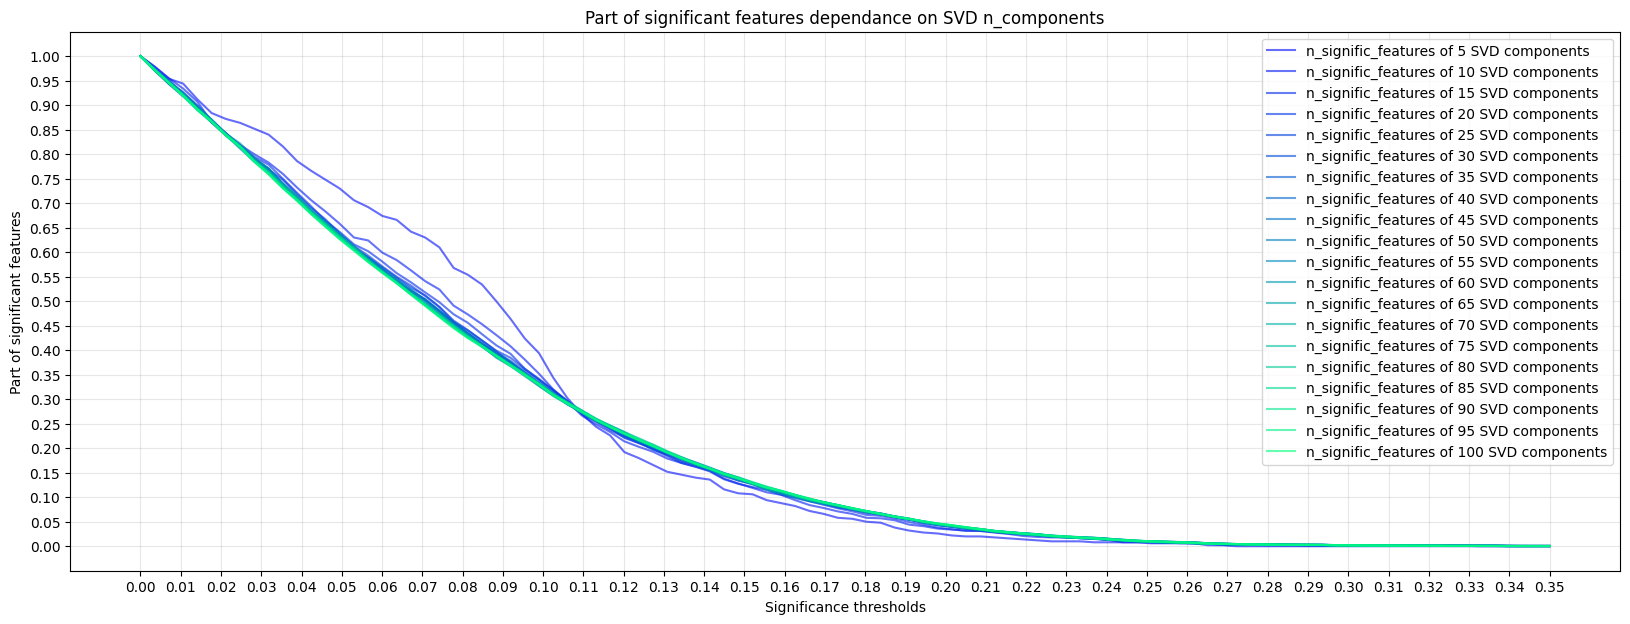

In [368]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().t().numpy(), 
    components_set=n_components_options,
    signific_feats_borders=(0, 0.35),
    in_part=True
)

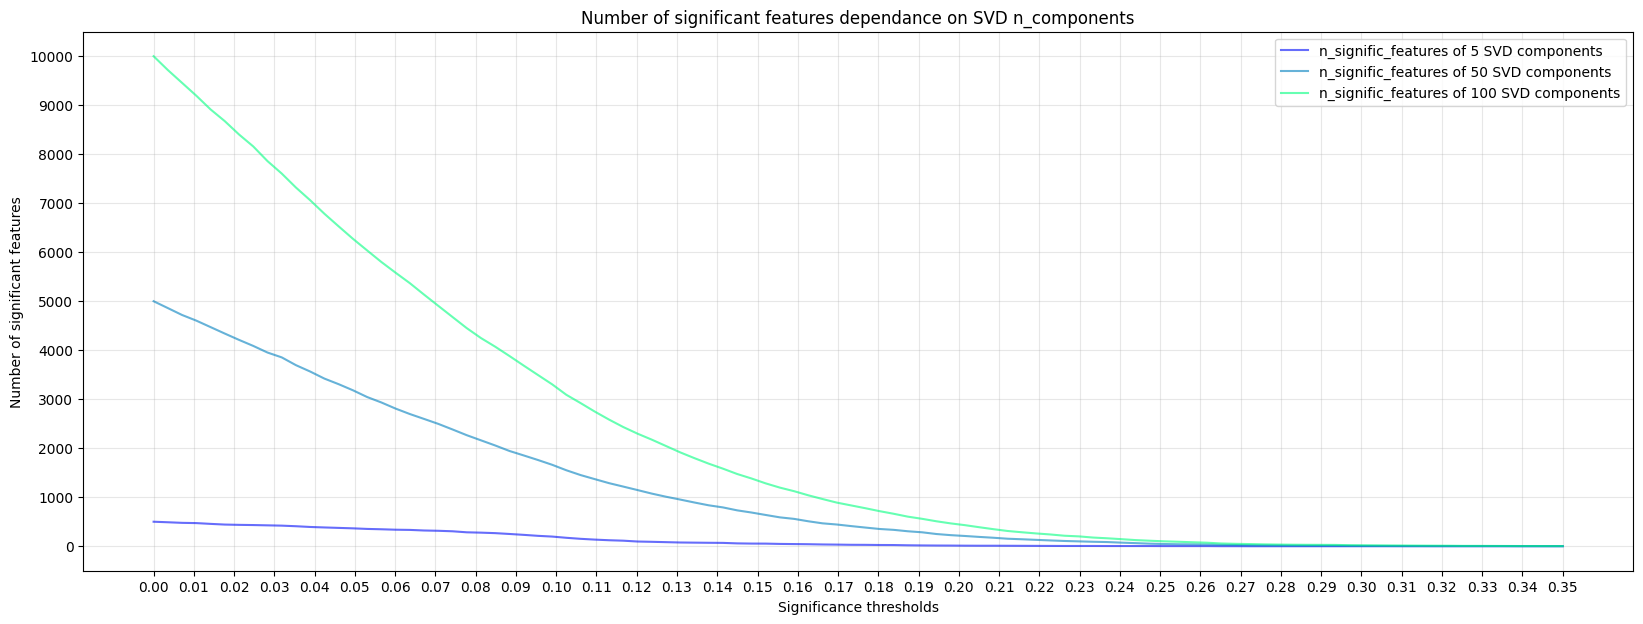

In [339]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().t().numpy(), 
    components_set=[5, 50, 100],
    signific_feats_borders=(0, 0.35)
)

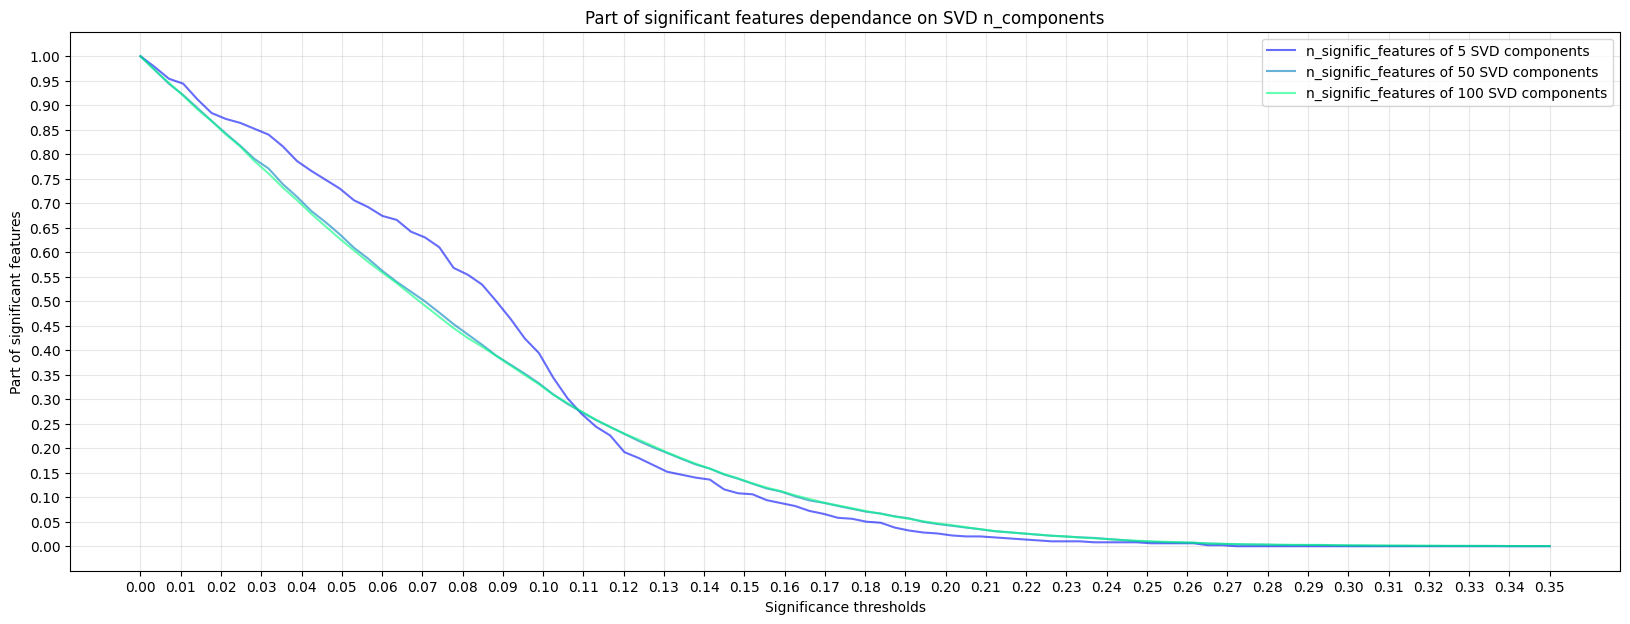

In [369]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().t().numpy(), 
    components_set=[5, 50, 100],
    signific_feats_borders=(0, 0.35),
    in_part=True
)

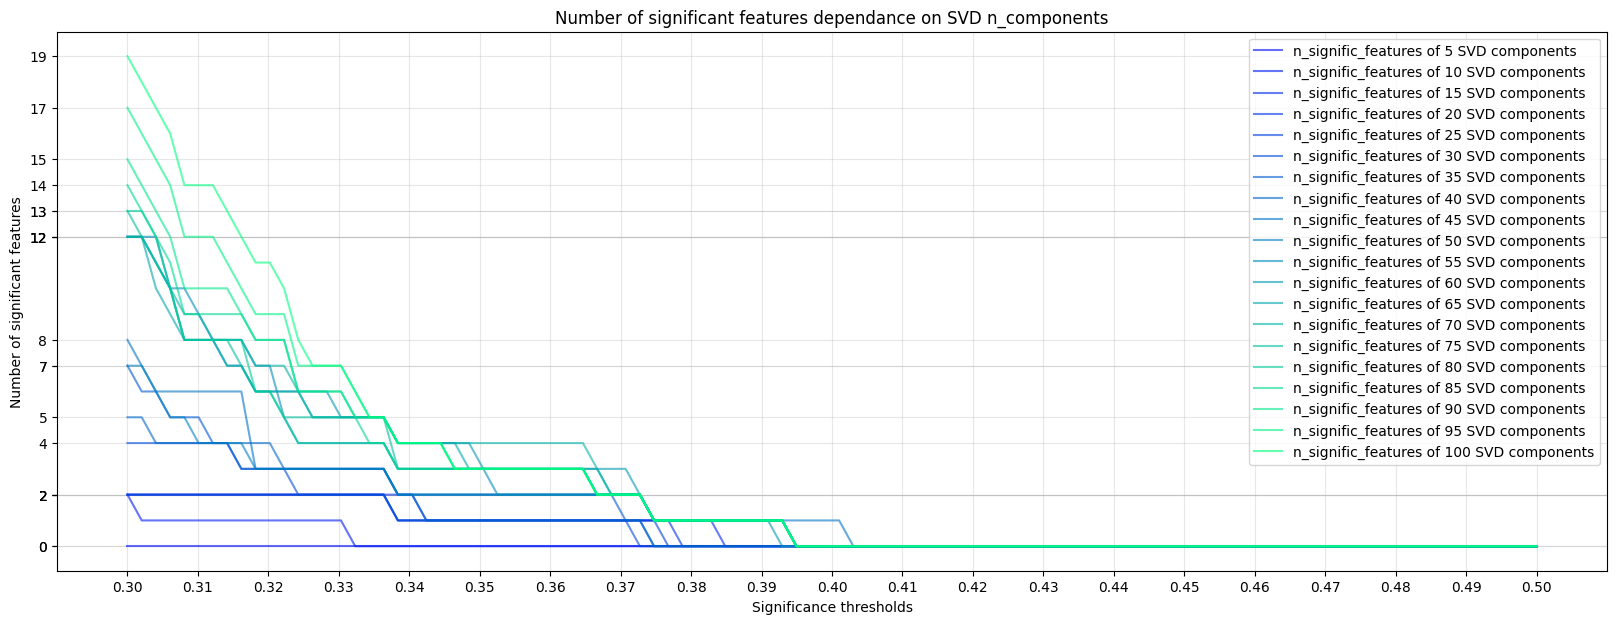

In [341]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().t().numpy(), 
    components_set=n_components_options,
    signific_feats_borders=(0.3, 0.5)
)

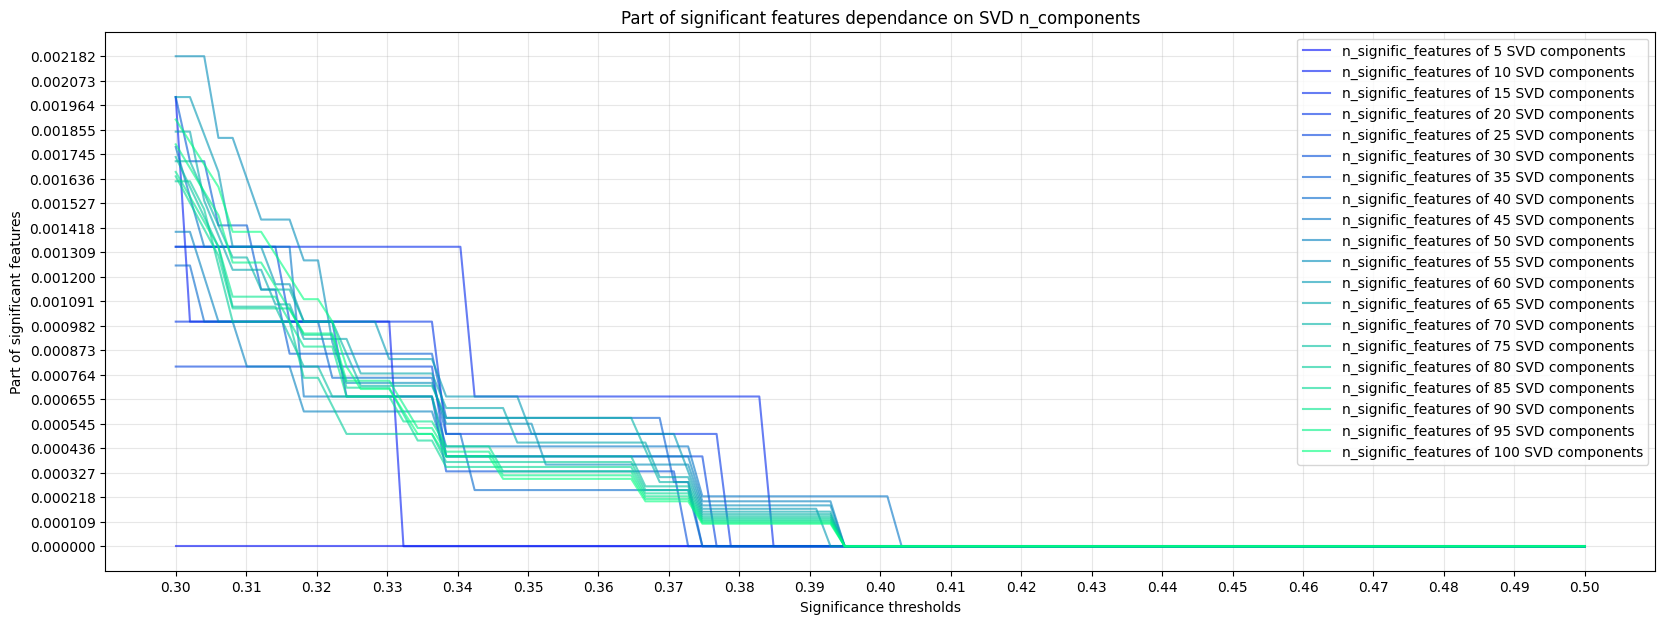

In [370]:
plot_n_signific_features_of_n_compts(
    weights_fused.cpu().t().numpy(), 
    components_set=n_components_options,
    signific_feats_borders=(0.3, 0.5),
    in_part=True
)

### Model performance dependance on significance threshold

In [ ]:
replace_linear(regnetx_3_2, weights_reduced)

tensor([-0.6758, -0.6985,  0.6573,  0.2781,  0.5307,  0.4333,  0.3613, -0.7660,
         0.4198, -1.1852, -0.0611, -0.1214, -1.2127,  0.2000, -0.3902, -1.2481,
         0.0024, -0.0372, -1.1961, -0.1601, -0.6242, -0.1621, -1.1598,  0.7109,
         0.0091, -0.0072, -1.4524,  1.4377, -0.0801, -0.4289,  0.7166, -0.5074,
        -0.1386, -0.2853,  0.0048,  0.4410,  0.4575,  0.5664,  0.6264,  0.2942,
        -1.3630,  0.2446,  0.3381, -0.2005,  0.4528, -0.2754, -0.2779,  0.6544,
         0.1163, -0.0836,  0.4593, -1.2665,  0.0859, -1.0792,  0.0987,  0.7963,
         0.3930, -0.1759,  0.3690,  1.0346, -0.3018,  0.4047,  0.2162, -0.4921,
         0.3673,  0.1397,  0.6375, -0.3741, -0.6850,  0.4071,  1.0267,  0.4269,
         0.3153, -0.4704,  0.9431, -0.1682, -0.6524, -0.0649,  0.4657, -0.1889,
         1.4278,  0.2752,  0.0335, -0.2316, -0.7006,  0.0668,  0.2869,  0.3745,
         0.3192,  0.7865,  0.1846, -0.2341, -0.6824,  0.1111, -0.5116, -0.6770,
        -0.6274, -0.0568,  0.5998, -0.48

In [ ]:
print("[ ] Validating model to check accuracy...")
_, checkpoint_acc = validate_epoch(regnetx_3_2, val_loader, criterion, device)
print("[V] Model has accuracy:", checkpoint_acc)

[ ] Validating model to check accuracy...
[V] Model has accuracy: 57.34


## ARCHIVE

### Significant classes' semantics analysis

ARCHIVED as the classes change completely with slight performance change.

In [14]:
top_classes_significance = mostleast_signific_classes(weights_fused.cpu().numpy(), 0, val_loader)
top_classes_significance["top_classes_ids"], top_classes_significance["top_classes_names"], \
top_classes_significance["bottom_classes_ids"], top_classes_significance["bottom_classes_names"]

(array([35, 69, 65, 93, 78]),
 ['girl', 'rocket', 'rabbit', 'turtle', 'snake'],
 array([87,  6, 91, 24, 37]),
 ['television', 'bee', 'trout', 'cockroach', 'house'])

In [15]:
def display_classes_examples(dataloader, classes_ids, n_examples: int=3):  
    classes_names = [dataloader.dataset.classes[class_id] for class_id in classes_ids]
    classes = {
        class_id: class_name
        for class_id, class_name in zip(classes_ids, classes_names)
    }
    images_to_show = []
    captions = []
    
    with torch.no_grad():
        for batch_images, batch_labels in dataloader:
            for image, label in zip(batch_images, batch_labels):
                label_num = label.item()
                if label_num in classes_ids:
                    class_name = classes[label_num]
                    if captions.count(class_name) < n_examples:
                        images_to_show.append(image)
                        captions.append(class_name)
            
            if all(captions.count(class_id) >= n_examples for class_id in classes_ids):
                break
    
    fig, axes = plt.subplots(
        len(classes_ids), 
        n_examples, 
        figsize=(n_examples * 2, len(classes_names) * 2)
    )
    
    for i, class_name in enumerate(classes_names):
        indices = [id for id, caption in enumerate(captions) if (caption == class_name)][:n_examples]
        
        for j, idx in enumerate(indices):
            ax = axes[i][j]
            image = images_to_show[idx].numpy().transpose(1, 2, 0)
            
            mean = [0.5071, 0.4867, 0.4408]
            std = [0.2675, 0.2565, 0.2761]
            image = std * image + mean
            image = np.clip(image, 0, 1)
            
            ax.imshow(image)
            ax.set_xticks([])
            ax.set_yticks([])
            
            if j == 0:
                ax.set_ylabel(class_name, rotation=0, ha='right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

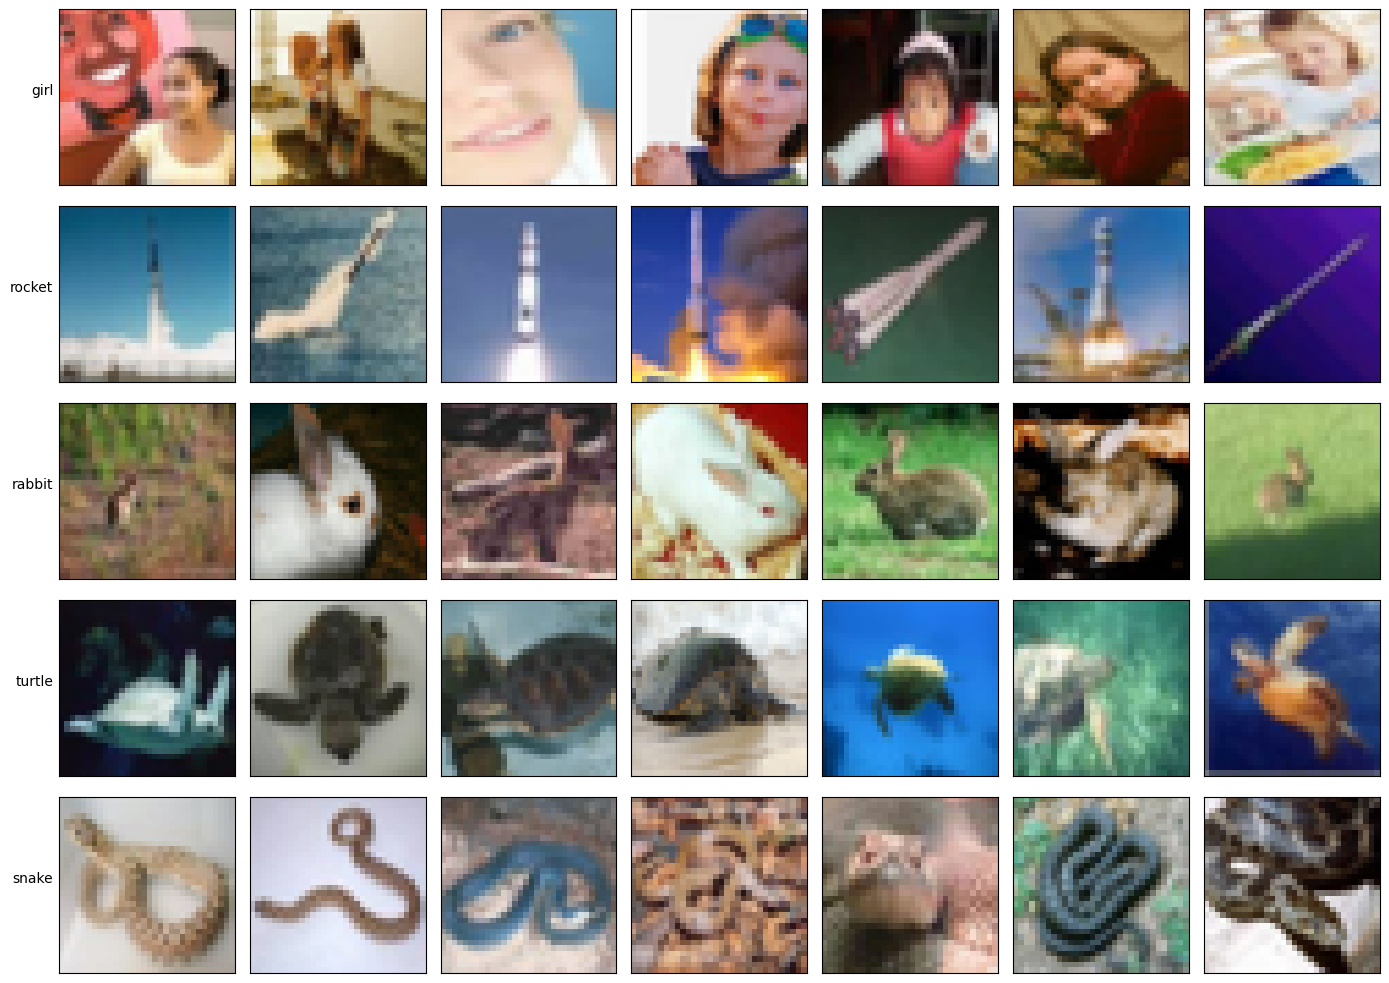

In [18]:
display_classes_examples(val_loader, top_classes_significance["top_classes_ids"], 7)

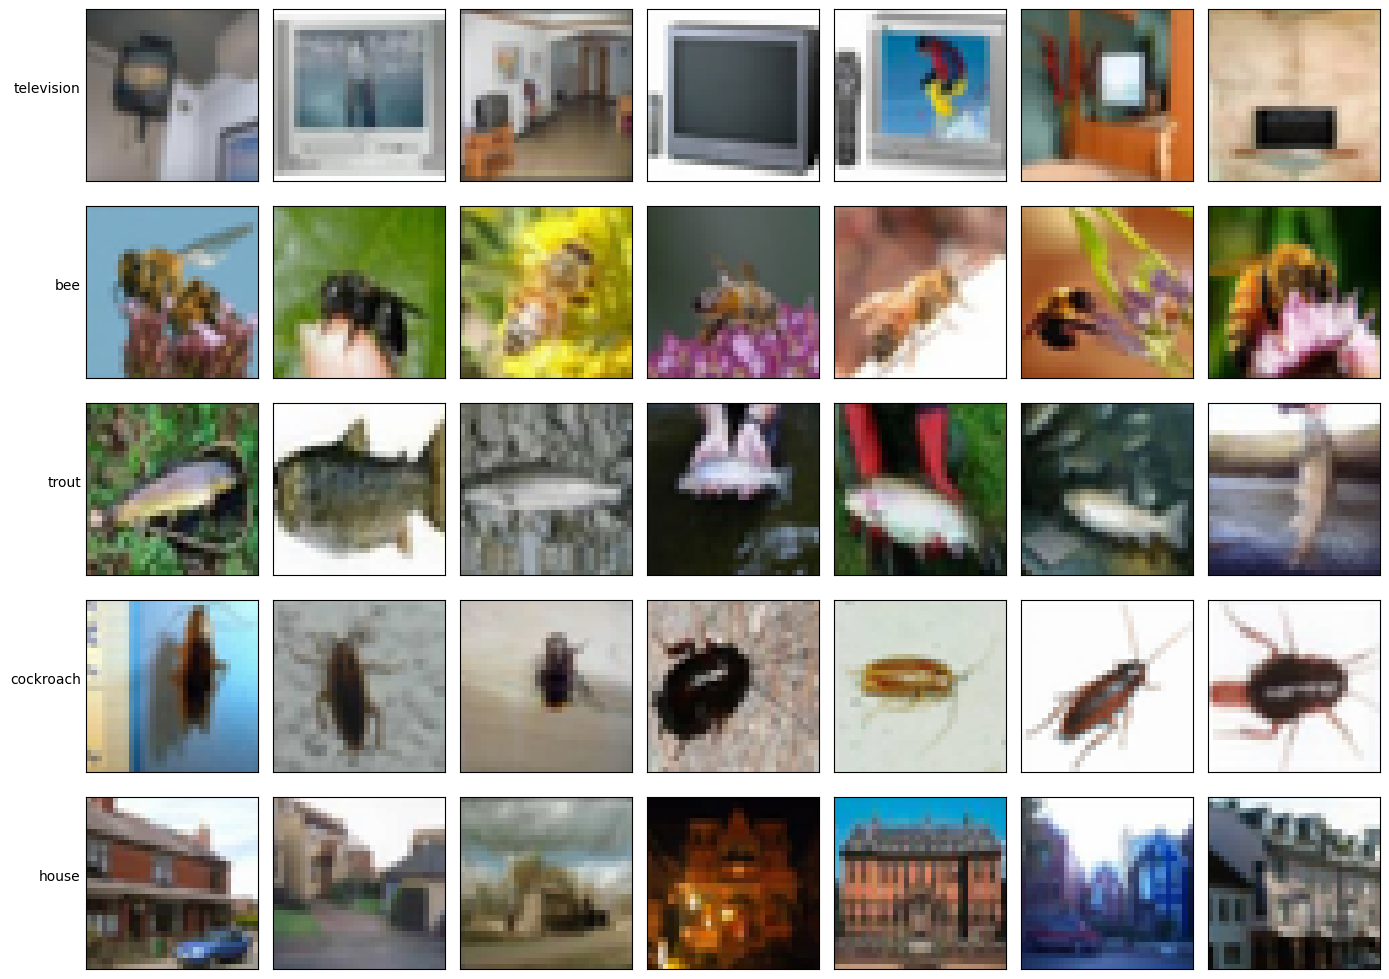

In [19]:
display_classes_examples(val_loader, top_classes_significance["bottom_classes_ids"], 7)